# Baryonic Boost: how to choose a backend and compute $C_\ell$s

Hydrodynamic baryonic processes (AGN feedback, gas cooling, stellar winds) suppress the
nonlinear matter power spectrum at scales $k \gtrsim 0.1\,h\,\mathrm{Mpc}^{-1}$.
Ignoring this suppression biases cosmological parameter inference from weak lensing.

`cloelib` exposes a common interface for baryonic suppression through the
`BaryonBoostMixin` Protocol in `cloelib.cosmology.cosmology`.  Three ready-made
backends are provided:

| Backend | Class | Baryonic parameters |
|---------|-------|---------------------|
| **FLAMINGO** | `CAMBNonLinearFLAMINGOPerturbations` | `fgas_sigma`, `Mstar_sigma`, `jet_fraction` |
| **BACCOemu** | `BACCOemuNonLinearBaryonicPerturbations` | 7 baryonic params (e.g. `M_c`, `eta`, …) |
| **HMcode2020emu** | `HMemuNonLinearBaryonicPerturbations` | `log10TAGN` |

Each of these produces a `Perturbations`-compatible object whose
`matter_power_spectrum` already includes the baryonic correction.
You can therefore drop it into any `cloelib` tracer or likelihood with **no extra
wrapping needed**.

> **Goal of this tutorial**
>
> 1. Show how to instantiate each baryonic perturbation backend.
> 2. Compare the baryonic suppression $B(k, z) = P_\mathrm{hydro}/P_\mathrm{DMO}$.
> 3. Feed the result into photo-$z$ tracers and compute $C_\ell$s, comparing the
>    auto-power spectra with and without baryonic suppression.

#### Summary

| | FLAMINGO | BACCOemu | HMcode2020 |
|--|----------|----------|------------|
| **Base perturbations** | CAMB nonlinear | BACCOemu nonlinear | HMcode2020emu nonlinear |
| **Baryonic params** | `fgas_sigma`, `Mstar_sigma`, `jet_fraction` | `M_c`, `eta`, `beta`, `M1_z0_cen`, `theta_out`, `theta_inn`, `M_inn` | `log10TAGN` |
| **Ratio pre-computed?** | No (per-z call to FRE at evaluation time) | Yes (bivariate spline at init) | Yes (bivariate spline at init) |
| **k units in `baryonic_suppression`** | h/Mpc (`k_hunit=True`) | 1/Mpc (default) | 1/Mpc (default) |
| **Valid $z$ range** | 0 – 3 | emulator bounds | emulator bounds |

All three classes are `Perturbations`-compatible and can be passed directly to any
`cloelib` tracer or likelihood.

In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import integrate

sns.set_theme(style="ticks")
plt.rc("xtick", labelsize=16)
plt.rc("ytick", labelsize=16)
plt.rc("font", size=16)
plt.rc("axes", titlesize=18)
plt.rc("axes", labelsize=16)
plt.rc("lines", linewidth=2)
plt.rc("legend", fontsize=13)

# cloelib: cosmology and tracers
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.cosmology.HMcode2020Emu_cosmology import (
    HMemuLinearPerturbations,
    HMemuNonLinearBaryonicPerturbations,
)
from cloelib.cosmology.baccoemu_cosmology import (
    BACCOemuLinearPerturbations,
    BACCOemuNonLinearPerturbations,
    BACCOemuNonLinearBaryonicPerturbations,
)
from cloelib.cosmology.FlamingoBaryonResponseEmulator_cosmology import (
    CAMBNonLinearFLAMINGOPerturbations,
)
from cloelib.cosmology.camb_cosmology import CAMBNonLinearPerturbations

from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint


/Users/guadalupecanasherrera/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


## 1 — Cosmological background

We use a single `CAMBBackground` instance throughout, shared by all three backends.
The neutrino setup (`N_mnu=1`, `mnu=0.06 eV`) is required by HMcode2020emu.

In [2]:
zs = np.linspace(1e-4, 3.0, 100)

background = CAMBBackground(
    H0=70.0,
    Omega_cdm0=0.25,
    Omega_b0=0.05,
    Omega_k0=0.0,
    As=2.1e-9,
    ns=0.966,
    mnu=0.06,
    w0=-1.0,
    wa=0.0,
    gamma_MG=0.545,
    N_mnu=1,
)
print(f"h = {background.h:.4f},  Omega_m0 = {background.Omega_cdm0 + background.Omega_b0:.4f}")

h = 0.7000,  Omega_m0 = 0.3000


## 2 — Building baryonic Perturbations objects

### 2a — FLAMINGO (CAMB back-end)

`CAMBNonLinearFLAMINGOPerturbations` combines a standard CAMB nonlinear run with
the FLAMINGO emulator response.  The three baryonic parameters describe ICM gas
and AGN jet physics calibrated on the FLAMINGO hydrodynamical simulations:

- `fgas_sigma` — offset from the calibrated intracluster gas fraction (in σ).
- `Mstar_sigma` — offset from the stellar mass function (in σ).
- `jet_fraction` — fraction of AGN energy in collimated jets (0 = thermal, 1 = jets).

The FLAMINGO emulator is only valid for $k \leq 10^{1.5}\,h\,\mathrm{Mpc}^{-1}$
and $z \leq 3$.  `cloelib` clamps $k$ and returns suppression = 1 outside those
ranges automatically.

In [3]:
# FLAMINGO: calibration offsets at fiducial (0, 0) and AGN jet fraction = 0 (thermal)
pert_flamingo = CAMBNonLinearFLAMINGOPerturbations(
    background=background,
    redshifts=zs,
    fgas_sigma=0.0,    # 0σ offset from calibration gas fraction
    Mstar_sigma=0.0,   # 0σ offset from stellar mass function
    jet_fraction=0.0,  # pure thermal AGN feedback
)
print("FLAMINGO  k range:", pert_flamingo.k[[0, -1]], "h/Mpc")

Note: redshifts have been re-sorted (earliest first)
FLAMINGO  k range: [4.99999995e-05 5.24999957e+02] h/Mpc


### 2b — BACCOemu

`BACCOemuNonLinearBaryonicPerturbations` runs the BACCOemu nonlinear emulator
**twice** at initialisation — once without baryons (DMO) and once with — and
stores $B(k,z) = P_\mathrm{baryon}/P_\mathrm{DMO}$ as a 2-D spline.

The 7 baryonic parameters follow the Aricò et al. (2021) baryonification model.
Default values (`None`) fall back to the emulator training-set defaults for the
selected `baryonic_model_name` (e.g. the Burger et al. 2025 best-fit).

In [4]:
# BACCOemu needs a linear-perturbations object first
linear_baccoemu = BACCOemuLinearPerturbations(background, zs)

# Baryonic perturbations: DMO + baryon ratio pre-computed at init
# All baryonic params are None → emulator's own defaults for "Burger2025"
pert_bacco = BACCOemuNonLinearBaryonicPerturbations(
    background=background,
    linearperturbations=linear_baccoemu,
    redshifts=zs,
    nonlinear_model_name="Arico2023",
    baryonic_model_name="Burger2025",
    # Optionally override individual baryonic params, e.g.:
    M_c=14.0,
    eta=-0.3,
    beta=-0.22,
    M1_z0_cen=10.5,
    theta_out=0.25,
    theta_inn=-0.86,
    M_inn=13.4
)
print("BACCOemu  k range:", pert_bacco.k[[0, -1]], "h/Mpc")

BACCOemu  k range: [7.e-05 5.e+02] h/Mpc


### 2c — HMcode2020emu

`HMemuNonLinearBaryonicPerturbations` uses a single scalar parameter `log10TAGN`
(the log₁₀ of the AGN heating temperature in Kelvin) to capture the baryonic
feedback amplitude.  Typical values: 7.6 (weak feedback) – 8.3 (strong feedback).

Again, the DMO and baryonic spectra are both computed at initialisation and their
ratio is stored as a spline, so run-time overhead is negligible.

In [5]:
# HMcode2020emu needs a linear-perturbations object first
linear_hmemu = HMemuLinearPerturbations(background, zs)

# Baryonic perturbations with log10TAGN = 7.8 (moderate AGN feedback)
pert_hmcode = HMemuNonLinearBaryonicPerturbations(
    background=background,
    linearperturbations=linear_hmemu,
    redshifts=zs,
    log10TAGN=7.8,
)
print("HMcode2020  k range:", pert_hmcode.k[[0, -1]], "h/Mpc")

HMcode2020  k range: [1.e-04 5.e+02] h/Mpc


## 3 — Comparing the baryonic suppression $B(k, z)$

All three classes expose `baryonic_suppression(zs, ks)` which returns
$B(k, z) = P_\mathrm{hydro}(k,z)/P_\mathrm{DMO}(k,z)$.
Below we compare them at three representative redshifts.

<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
/var/folders/b1/qymrqldd3fdbp79s76djm9240000gn/T/ipykernel_84313/3179976956.py:29: SyntaxWarning: invalid escape sequence '\m'
  ax.semilogx(k_plot, B_hmcode,  label="HMcode2020 ($T_{\mathrm{AGN}}=10^{7.8}$ K)",


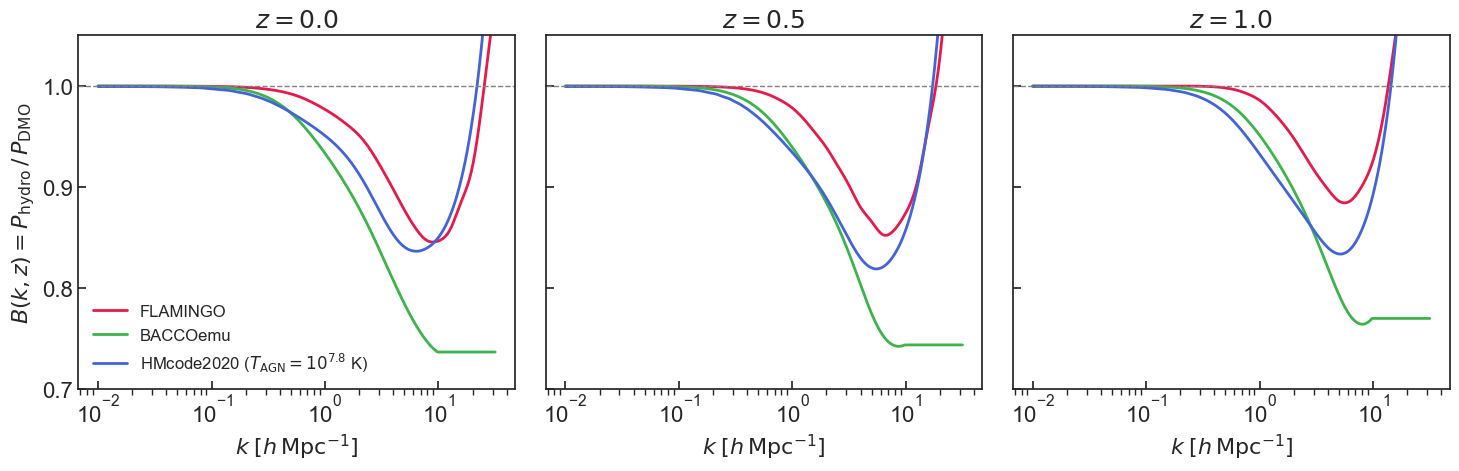

In [6]:
# Shared k grid for comparison (in h/Mpc, as used by cloelib internally)
k_plot = np.logspace(-2, 1.5, 200)

z_slices = [0.0, 0.5, 1.0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

colors = {"FLAMINGO": "#e6194B", "BACCOemu": "#3cb44b", "HMcode2020": "#4363d8"}

for ax, z_val in zip(axes, z_slices):
    zv = np.array([z_val])

    # FLAMINGO: baryonic_suppression is called with k in h/Mpc (k_hunit=True)
    B_flamingo = pert_flamingo.baryonic_suppression(zv, k_plot, k_hunit=True)[0]

    # BACCOemu: k stored internally in h/Mpc, suppression also in h/Mpc
    k_bacco = k_plot * background.h / background.h  # no change; already h/Mpc
    B_bacco = pert_bacco.baryonic_suppression(
        zv, k_plot * background.h, k_hunit=False
    )[0]  # pass 1/Mpc (default)

    # HMcode2020: same convention
    B_hmcode = pert_hmcode.baryonic_suppression(
        zv, k_plot * background.h, k_hunit=False
    )[0]

    ax.semilogx(k_plot, B_flamingo, label="FLAMINGO", color=colors["FLAMINGO"])
    ax.semilogx(k_plot, B_bacco,   label="BACCOemu",  color=colors["BACCOemu"])
    ax.semilogx(k_plot, B_hmcode,  label="HMcode2020 ($T_{\mathrm{AGN}}=10^{7.8}$ K)",
                color=colors["HMcode2020"])

    ax.axhline(1.0, color="gray", lw=1, ls="--")
    ax.set_title(f"$z = {z_val}$")
    ax.set_xlabel(r"$k\;[h\,\mathrm{Mpc}^{-1}]$")
    ax.tick_params(direction="in")

axes[0].set_ylabel(r"$B(k,z) = P_\mathrm{hydro}\,/\,P_\mathrm{DMO}$")
axes[0].legend(frameon=False, fontsize=12)
axes[0].set_ylim(0.7, 1.05)

plt.tight_layout()
plt.show()

## 4 — Effect on $P(k)$: baryon vs. DMO

Let's also look at the total matter power spectrum with and without baryonic
suppression at a single benchmark redshift $z = 0.5$.

Note: redshifts have been re-sorted (earliest first)


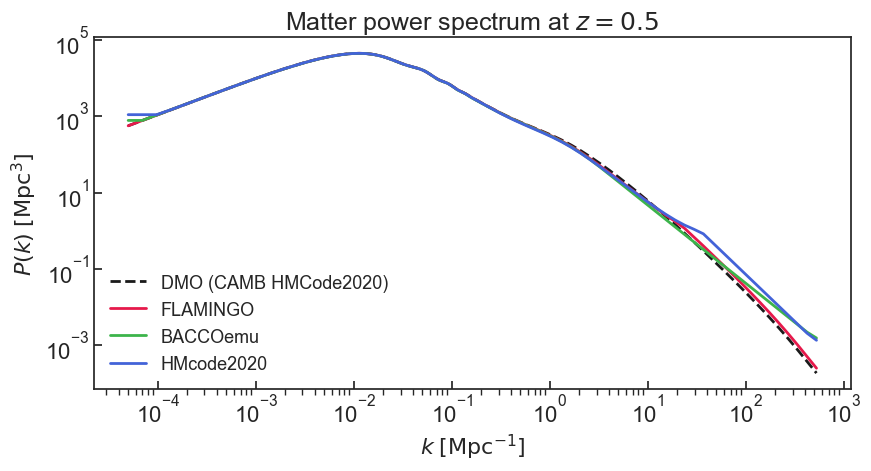

In [7]:
# DMO baseline: CAMB nonlinear (no baryons)
pert_dmo = CAMBNonLinearPerturbations(background=background, redshifts=zs)

z_ref = np.array([0.5])

# Evaluation k (1/Mpc, the internal convention of cloelib)
k_eval = pert_dmo.k

Pk_dmo      = pert_dmo.matter_power_spectrum(z_ref, k_eval)
Pk_flamingo = pert_flamingo.matter_power_spectrum(z_ref, k_eval)
Pk_bacco    = pert_bacco.matter_power_spectrum(z_ref, k_eval)
Pk_hmcode   = pert_hmcode.matter_power_spectrum(z_ref, k_eval)

fig, ax = plt.subplots(figsize=(9, 5))

ax.loglog(k_eval, Pk_dmo,      "k--",  label="DMO (CAMB HMCode2020)",  lw=2)
ax.loglog(k_eval, Pk_flamingo, color=colors["FLAMINGO"], label="FLAMINGO")
ax.loglog(k_eval, Pk_bacco,    color=colors["BACCOemu"],  label="BACCOemu")
ax.loglog(k_eval, Pk_hmcode,   color=colors["HMcode2020"], label="HMcode2020")

ax.set_xlabel(r"$k\;[\mathrm{Mpc}^{-1}]$")
ax.set_ylabel(r"$P(k)\;[\mathrm{Mpc}^3]$")
ax.set_title(r"Matter power spectrum at $z = 0.5$")
ax.legend(frameon=False)
ax.tick_params(direction="in")
plt.tight_layout()
plt.show()


## 5 — Galaxy redshift distributions $n(z)$

We build simple toy redshift distributions for 6 tomographic bins to be used
for the tracer and $C_\ell$ computation in the next section.

In [8]:
import os
import requests
import euclidlib as el

# Download n(z) file from Zenodo (once)
data_downloaded = False
nz_filename = "nz_example.fits"
nz_url = "https://zenodo.org/records/15092862/files/nz_example.fits"

if not data_downloaded:

    if not os.path.exists(nz_filename):
        r = requests.get(nz_url, timeout=60)
        r.raise_for_status()
        with open(nz_filename, "wb") as f:
            f.write(r.content)
        print(f"{nz_filename} downloaded successfully")
    else:
        print(f"{nz_filename} already exists, skipping download")
    data_downloaded = True

# Read FITS and extract z + tomographic n(z)

print("Reading n(z) from FITS file...")
z_nz, nz_example = el.phz.redshift_distributions('nz_example.fits')
print("Done.")


nz_example.fits already exists, skipping download
Reading n(z) from FITS file...
Done.


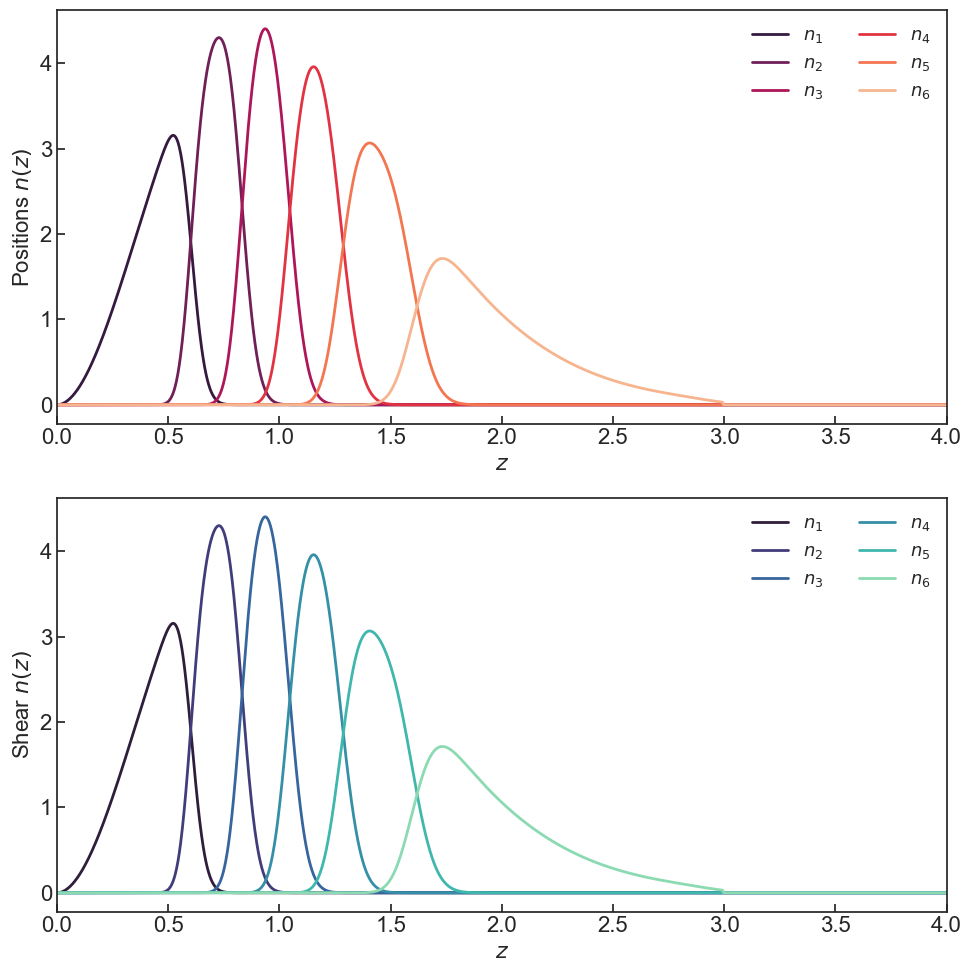

In [9]:
# Function to normalize dndz
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_example, z_nz)
dndz_she_norm = normalize_dndz(nz_example, z_nz)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values()))
    my_dndz_norm = np.zeros([len(nz_example), len(myz)])
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :])
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, zs)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, zs)

# Plotting dndz
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i, (key, color) in enumerate(zip(dndz_pos_norm.keys(), sns.color_palette("rocket", len(dndz_pos_norm)))):
    axs[0].plot(z_nz, dndz_pos_norm[key], label=f'$n_{{{i+1}}}$', linewidth=2, color=color)

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm.keys(), sns.color_palette("mako", len(dndz_she_norm)))):
    axs[1].plot(z_nz, dndz_she_norm[key], label=f'$n_{{{j+1}}}$', linewidth=2, color=color)

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 4)
axs[0].legend(frameon=False, ncol=2)

axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 4)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()

## 6 — Tracers and angular power spectra

We build `ShearTracer` and `PositionsTracer` objects and compute the 3×2pt
angular power spectra.  The key point is that **every baryonic perturbations
object is a drop-in replacement** for the DMO one; the tracer and
`AngularTwoPoint` API is identical regardless of the backend.

> **Reading the $C_\ell$ dictionary**  
> `AngularTwoPoint.get_Cl(ells, 0, ks)` returns a dict keyed by
> `(probe1, probe2, bin_i, bin_j)`, e.g. `cells['SHE', 'SHE', 1, 1]`.
> `'SHE'` = cosmic shear (E-mode), `'POS'` = galaxy clustering.

In [10]:
n_bins = 6

In [11]:
nuisance_pos = {
    "b1_photo_poly0": 1.0, "b1_photo_poly1": 0.0,
    "b1_photo_poly2": 0.0, "b1_photo_poly3": 0.0,
    **{f"magnification_bias_{i}": 0.0 for i in range(1, n_bins + 1)},
    **{f"dz_pos_{i}": 0.0 for i in range(1, n_bins + 1)},
}
nuisance_she = {
    "AIA": 1.72, "CIA": 0.0134, "EtaIA": -0.41,
    **{f"multiplicative_bias_{i}": 0.0 for i in range(1, n_bins + 1)},
    **{f"dz_shear_{i}": 0.0 for i in range(1, n_bins + 1)},
}

ells = np.logspace(1.0, np.log10(3000), 60)


def build_cells(perturbations):
    """Return the 3x2pt Cell dict for a given perturbations object."""
    tracer_pos = PositionsTracer(
        perturbations=perturbations,
        dndz=my_dndz_pos_norm,
        z=zs,
        galaxy_bias_model="poly",
        nuisance_params=nuisance_pos,
    )
    tracer_she = ShearTracer(
        perturbations=perturbations,
        dndz=my_dndz_she_norm,
        z=zs,
        nuisance_params=nuisance_she,
    )
    tp_gg = AngularTwoPoint(tracer_pos, tracer_pos)
    tp_gs = AngularTwoPoint(tracer_pos, tracer_she)
    tp_ss = AngularTwoPoint(tracer_she, tracer_she)
    return {
        **tp_gg.get_Cl(ells, 0, perturbations.k),
        **tp_gs.get_Cl(ells, 0, perturbations.k),
        **tp_ss.get_Cl(ells, 0, perturbations.k),
    }


print("Computing C_ells for all backends…")
cells_dmo      = build_cells(pert_dmo)
cells_flamingo = build_cells(pert_flamingo)
cells_bacco    = build_cells(pert_bacco)
cells_hmcode   = build_cells(pert_hmcode)
print("Done.")

Computing C_ells for all backends…
Done.


### 6a — Weak-lensing auto-spectra $C_\ell^{\gamma\gamma}$

The diagonal bins show the effect most clearly.  At high $\ell$ all baryonic
backends suppress power relative to DMO, with FLAMINGO typically showing the
largest suppression at $z \sim 0$ and BACCOemu the flattest response.

In [12]:
n_bins = 6

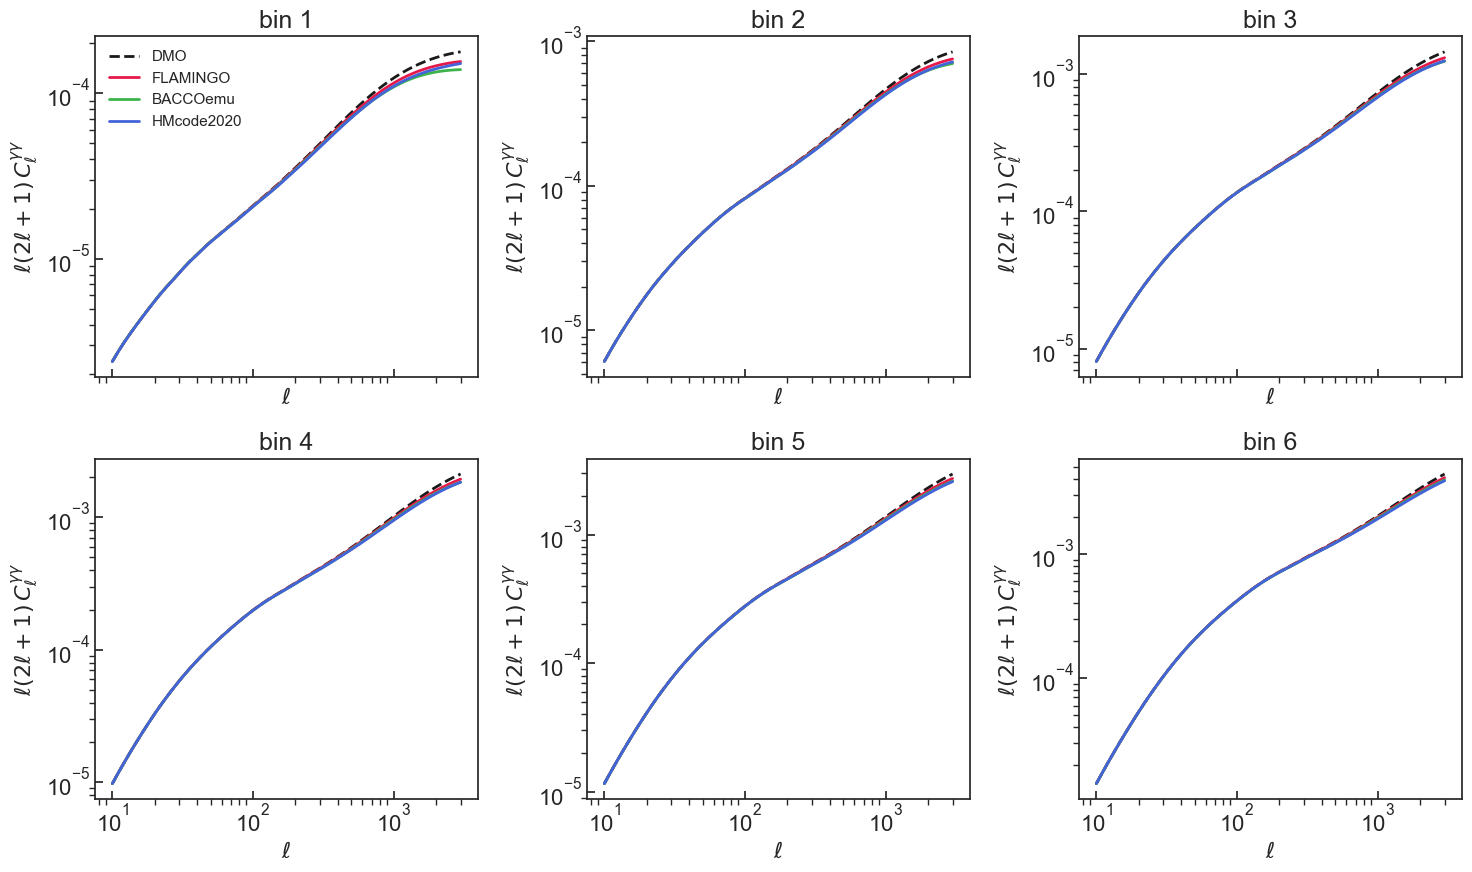

In [13]:

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True)
axes = axes.flatten()
palette_bins = sns.color_palette("mako", n_bins)

for idx, i in enumerate(range(1, n_bins + 1)):
    ax = axes[idx]
    key = ("SHE", "SHE", i, i)

    Cl_dmo      = cells_dmo[key][0, 0]
    Cl_flamingo = cells_flamingo[key][0, 0]
    Cl_bacco    = cells_bacco[key][0, 0]
    Cl_hmcode   = cells_hmcode[key][0, 0]
    ell         = cells_dmo[key].ell

    norm = ell * (2 * ell + 1)

    ax.loglog(ell, norm * Cl_dmo,      "k--",  lw=2,  label="DMO")
    ax.loglog(ell, norm * Cl_flamingo, color=colors["FLAMINGO"], label="FLAMINGO")
    ax.loglog(ell, norm * Cl_bacco,    color=colors["BACCOemu"],  label="BACCOemu")
    ax.loglog(ell, norm * Cl_hmcode,   color=colors["HMcode2020"], label="HMcode2020")

    ax.set_title(f"bin {i}")
    ax.tick_params(direction="in")
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(r"$\ell(2\ell+1)\,C_\ell^{\gamma\gamma}$")

axes[0].legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

### 6b — Fractional baryonic effect $\Delta C_\ell / C_\ell^{\rm DMO}$

Plotting the fractional difference with respect to the DMO baseline makes the
effect of each backend immediately comparable.

In [14]:
n_bins = 6

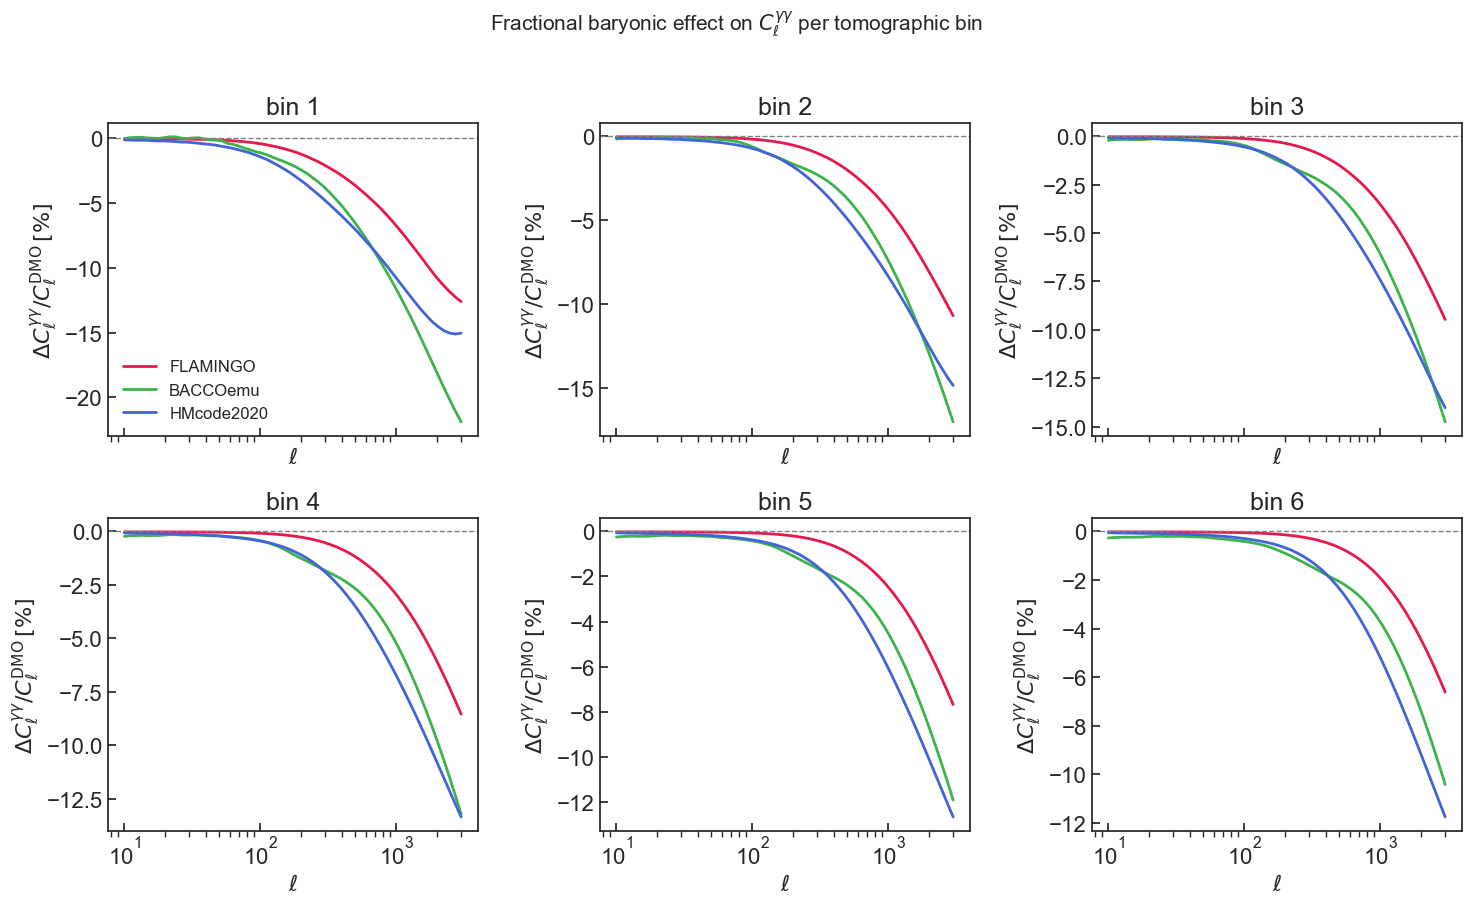

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True)
axes = axes.flatten()

for idx, i in enumerate(range(1, n_bins + 1)):
    ax = axes[idx]
    key = ("SHE", "SHE", i, i)

    Cl_dmo      = cells_dmo[key][0, 0]
    ell         = cells_dmo[key].ell

    for label, cells_dict, color in [
        ("FLAMINGO", cells_flamingo, colors["FLAMINGO"]),
        ("BACCOemu", cells_bacco,   colors["BACCOemu"]),
        ("HMcode2020", cells_hmcode, colors["HMcode2020"]),
    ]:
        Cl = cells_dict[key][0, 0]
        ax.semilogx(ell, (Cl - Cl_dmo) / Cl_dmo * 100, color=color, label=label)

    ax.axhline(0, color="gray", lw=1, ls="--")
    ax.set_title(f"bin {i}")
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(r"$\Delta C_\ell^{\gamma\gamma} / C_\ell^{\rm DMO}\,[\%]$")
    ax.tick_params(direction="in")

axes[0].legend(frameon=False, fontsize=12)
plt.suptitle(
    r"Fractional baryonic effect on $C_\ell^{\gamma\gamma}$ per tomographic bin",
    fontsize=15, y=1.01,
)
plt.tight_layout()
plt.show()

### 6c — Galaxy clustering auto-spectra $C_\ell^{gg}$

Baryonic effects on galaxy clustering are much smaller because the galaxy bias
suppresses the response, but they are non-zero at high $\ell$.

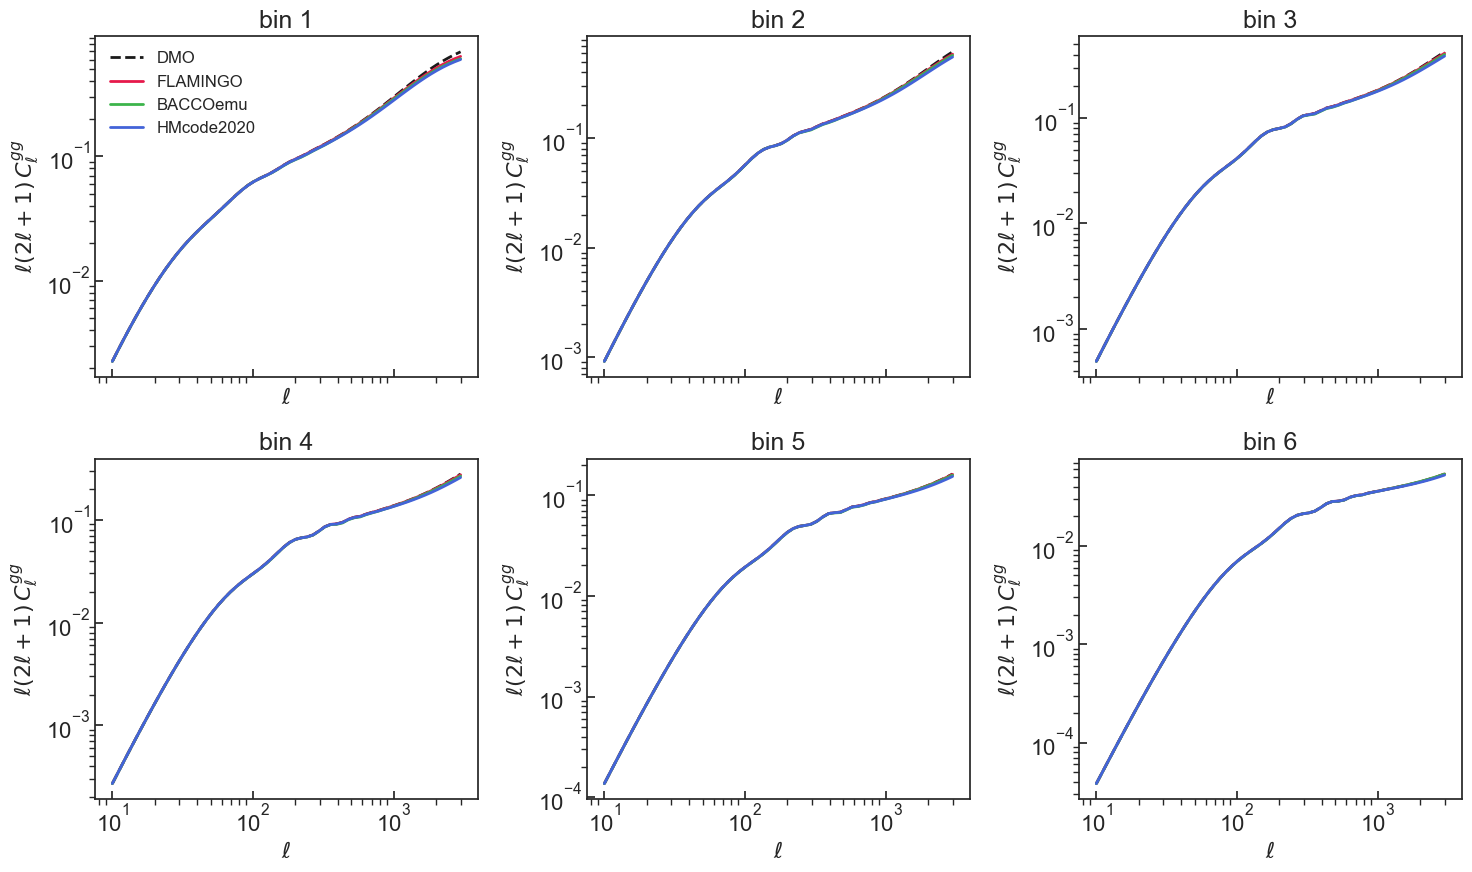

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True)
axes = axes.flatten()

for idx, i in enumerate(range(1, n_bins + 1)):
    ax = axes[idx]
    key = ("POS", "POS", i, i)

    Cl_dmo = cells_dmo[key]
    ell    = Cl_dmo.ell

    ax.loglog(ell, ell * (2 * ell + 1) * Cl_dmo,      "k--", lw=2, label="DMO")
    for label, cells_dict, color in [
        ("FLAMINGO", cells_flamingo, colors["FLAMINGO"]),
        ("BACCOemu", cells_bacco,   colors["BACCOemu"]),
        ("HMcode2020", cells_hmcode, colors["HMcode2020"]),
    ]:
        ax.loglog(ell, ell * (2 * ell + 1) * cells_dict[key], color=color, label=label)

    ax.set_title(f"bin {i}")
    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(r"$\ell(2\ell+1)\,C_\ell^{gg}$")
    ax.tick_params(direction="in")

axes[0].legend(frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

### Executable example of how to compose your own class compatible with Perturbations

This section shows a **minimal, executable pattern** to build your own baryonic backend class while staying fully compatible with `Perturbations`.

The idea is:

1. Start from any nonlinear perturbations class (here: `BACCOemuNonLinearPerturbations`).
2. Add a baryonic mixin (here: `FlamingoBaryonBoostMixin`).
3. Initialize both parts explicitly.
4. Use the resulting object exactly like any other `Perturbations` instance.

```python
class BACCOemuFLAMINGOPerturbations(
    FlamingoBaryonBoostMixin,
    BACCOemuNonLinearPerturbations,
):
    def __init__(
        self,
        background,
        linearperturbations,
        redshifts,
        *,
        fgas_sigma=0.0,
        Mstar_sigma=0.0,
        jet_fraction=0.0,
        **nonlinear_kwargs,
    ):
        BACCOemuNonLinearPerturbations.__init__(
            self,
            background=background,
            linearperturbations=linearperturbations,
            redshifts=redshifts,
            **nonlinear_kwargs,
        )
        FlamingoBaryonBoostMixin.__init__(
            self,
            fgas_sigma=fgas_sigma,
            Mstar_sigma=Mstar_sigma,
            jet_fraction=jet_fraction,
        )


pert_bacco_flamingo_A = BACCOemuFLAMINGOPerturbations(
    background=background,
    linearperturbations=linear_baccoemu,
    redshifts=zs,
    nonlinear_model_name="Arico2023",
    fgas_sigma=0.0,
    Mstar_sigma=0.0,
    jet_fraction=0.0,
)

Pk_bacco_with_flamingo_A = pert_bacco_flamingo_A.matter_power_spectrum(z_ref, k_eval)
```

Because this object exposes the standard `Perturbations` interface (`k`, `matter_power_spectrum`, etc.), it can be passed directly to `ShearTracer`, `PositionsTracer`, and `AngularTwoPoint` with no further changes.  
In the next cell, the factory approach (`with_baryon_boost`) provides the same composition in a one-liner.


In [17]:
from cloelib.cosmology.cosmology import with_baryon_boost
from cloelib.cosmology.FlamingoBaryonResponseEmulator_cosmology import FlamingoBaryonBoostMixin
from cloelib.cosmology.baccoemu_cosmology import BACCOemuNonLinearPerturbations


# --------------------------------------------------------------------------
# Option B: with_baryon_boost factory  (one-liner, zero boilerplate)
# All nonlinear args pass through normally; mixin args go in baryon_kwargs.
# --------------------------------------------------------------------------

BACCOemuNonLinearFLAMINGO = with_baryon_boost(BACCOemuNonLinearPerturbations, FlamingoBaryonBoostMixin)
pert_bacco_flamingo = BACCOemuNonLinearFLAMINGO(
    background, linear_baccoemu, zs,
    nonlinear_model_name="Arico2023",
    baryon_kwargs=dict(fgas_sigma=0.0, Mstar_sigma=0.0, jet_fraction=0.0),
)

Pk_bacco_with_flamingo = pert_bacco_flamingo.matter_power_spectrum(z_ref, k_eval)


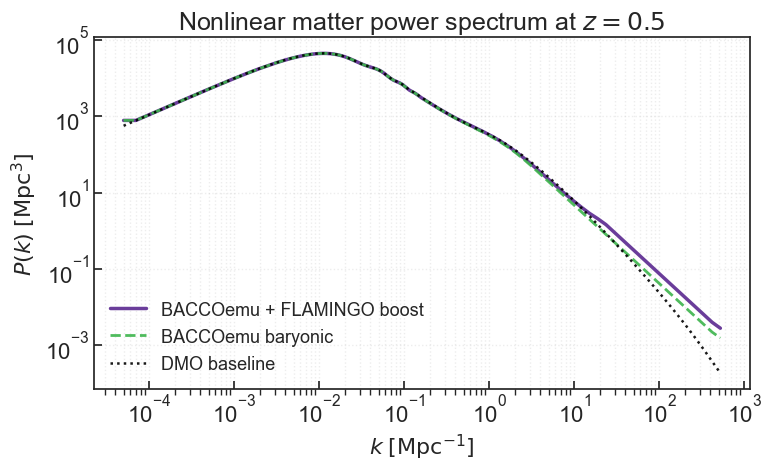

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.loglog(
    k_eval,
    Pk_bacco_with_flamingo,
    color="#6a3d9a",
    lw=2.5,
    label="BACCOemu + FLAMINGO boost",
)

# Optional references (already available in the notebook)
ax.loglog(k_eval, Pk_bacco, color="#3cb44b", lw=2, ls="--", alpha=0.9, label="BACCOemu baryonic")
ax.loglog(k_eval, Pk_dmo, color="black", lw=1.8, ls=":", alpha=0.9, label="DMO baseline")

ax.set_xlabel(r"$k\;[\mathrm{Mpc}^{-1}]$")
ax.set_ylabel(r"$P(k)\;[\mathrm{Mpc}^3]$")
ax.set_title(r"Nonlinear matter power spectrum at $z={}$".format(z_ref[0]))
ax.grid(True, which="both", ls=":", alpha=0.35)
ax.legend(frameon=False)
ax.tick_params(direction="in")

plt.tight_layout()
plt.show()

In [ ]:
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuNonLinearPerturbations

# HMcode2020 DMO nonlinear + custom Eq.(6) baryonic boost https://arxiv.org/pdf/2504.15633

class Eq6BaryonBoostMixin:
    def __init__(self, A0=0.18, k0=0.7, alpha=1.2, beta=2.0):
        self.A0 = A0
        self.k0 = k0
        self.alpha = alpha
        self.beta = beta

    def baryonic_suppression(self, zs_eval, ks_eval, k_hunit=False):
        z = np.atleast_1d(zs_eval).astype(float)   # (Nz,)
        k = np.atleast_1d(ks_eval).astype(float)   # (Nk,)

        # Eq.(6) written in h/Mpc
        k_hmpc = k if k_hunit else (k / self.background.h)

        Az = self.A0 / (1.0 + z)[:, None]
        x = k_hmpc[None, :] / self.k0
        B = 1.0 - Az * (x ** self.alpha) / (1.0 + x ** self.beta)

        return np.clip(B, 0.0, 1.2)

# Compose Eq.(6) boost on top of HMcode2020Emu nonlinear DMO
HMcodeNonLinearEq6Perturbations = with_baryon_boost(
    HMemuNonLinearPerturbations,
    Eq6BaryonBoostMixin,
)

# DMO HMcode2020 baseline and Eq.(6)-boosted version
pert_hm_dmo = HMemuNonLinearPerturbations(
    background=background,
    linearperturbations=linear_hmemu,
    redshifts=zs,
    log10TAGN=7.8,  # same AGN feedback as in pert_hmcode, but no boost
)

pert_eq6 = HMcodeNonLinearEq6Perturbations(
    background,
    linear_hmemu,
    zs,
    baryon_kwargs=dict(A0=0.18, k0=0.7, alpha=1.2, beta=2.0),
)

# Compare at z_ref
k_eval_hm = np.asarray(pert_hm_dmo.k).ravel()  # 1/Mpc
B_eq6 = pert_eq6.baryonic_suppression(z_ref, k_eval_hm, k_hunit=False)[0]

Pk_hm_dmo = np.asarray(pert_hm_dmo.matter_power_spectrum(z_ref, k_eval_hm)).ravel()
Pk_eq6 = np.asarray(pert_eq6.matter_power_spectrum(z_ref, k_eval_hm)).ravel()

z0 = float(z_ref[0])

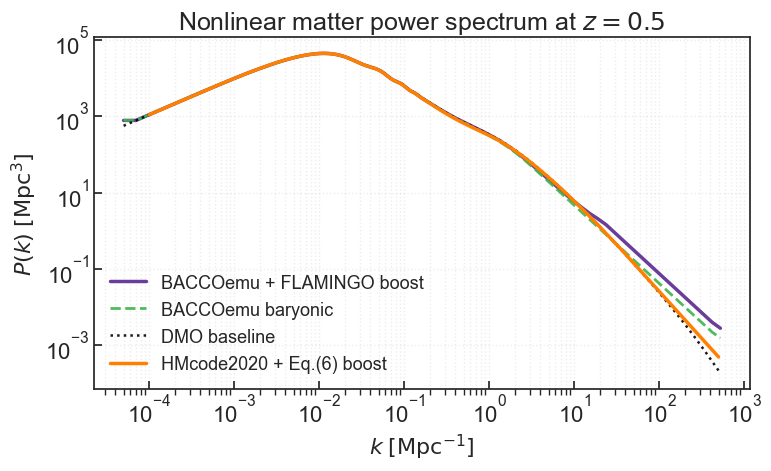

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.loglog(
    k_eval,
    Pk_bacco_with_flamingo,
    color="#6a3d9a",
    lw=2.5,
    label="BACCOemu + FLAMINGO boost",
)

# Optional references (already available in the notebook)
ax.loglog(k_eval, Pk_bacco, color="#3cb44b", lw=2, ls="--", alpha=0.9, label="BACCOemu baryonic")
ax.loglog(k_eval, Pk_dmo, color="black", lw=1.8, ls=":", alpha=0.9, label="DMO baseline")
ax.loglog(k_eval_hm, Pk_eq6, color="#ff7f00", lw=2.5, label="HMcode2020 + Eq.(6) boost")

ax.set_xlabel(r"$k\;[\mathrm{Mpc}^{-1}]$")
ax.set_ylabel(r"$P(k)\;[\mathrm{Mpc}^3]$")
ax.set_title(r"Nonlinear matter power spectrum at $z={}$".format(z_ref[0]))
ax.grid(True, which="both", ls=":", alpha=0.35)
ax.legend(frameon=False)
ax.tick_params(direction="in")

plt.tight_layout()
plt.show()